In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/train.csv")

df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [6]:
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
Duplicate Rows: 0


In [7]:
df['Postal Code'].fillna(df['Postal Code'].mode()[0], inplace=True)

/tmp/ipykernel_1359/897664930.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Postal Code'].fillna(df['Postal Code'].mode()[0], inplace=True)


In [8]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [10]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Average Shipping Time:", df['Shipping Days'].mean())
print(df.groupby('Region')['Shipping Days'].mean())

Average Shipping Time: 3.9611224489795918
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


In [15]:
df['Month Name'] = df['Order Date'].dt.strftime('%B')
monthly_pattern = df.groupby('Month Name')['Sales'].sum()
print(monthly_pattern)

Month Name
April        136283.0006
August       157315.9270
December     321480.1695
February      59371.1154
January       94291.6296
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     350161.7110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64


In [16]:
!pip install statsmodels

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt

In [18]:
monthly_sales = df.groupby(
    pd.Grouper(
        key='Order Date',
        freq='M'
    )
)['Sales'].sum()

monthly_sales.head()

/tmp/ipykernel_1359/2537192999.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


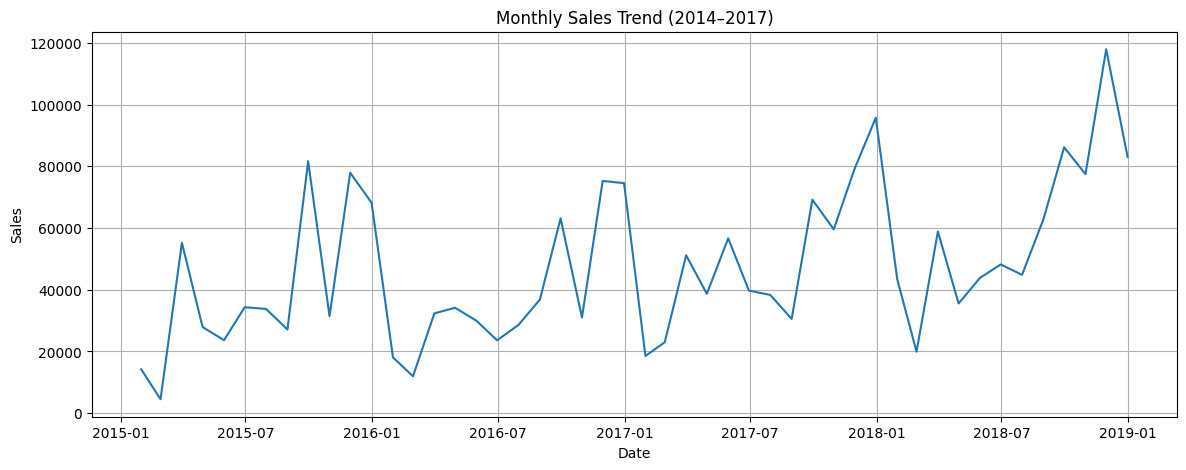

In [21]:
import os

plt.figure(figsize=(14,5))

plt.plot(monthly_sales)

plt.title("Monthly Sales Trend (2014–2017)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

# Create the directory if it doesn't exist
output_dir = "/content/charts"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "monthly_sales_trend.png"))

plt.show()

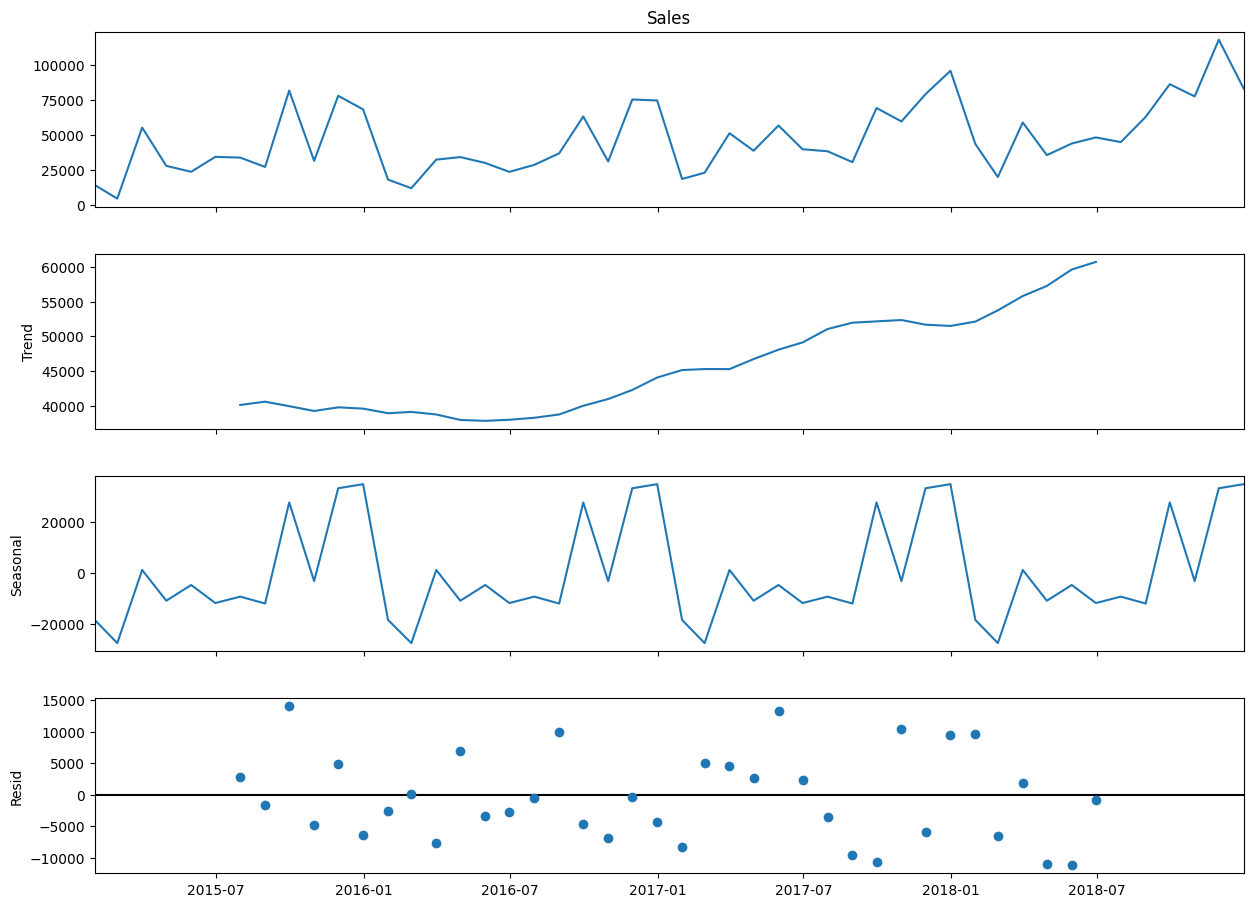

In [22]:
decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.savefig("charts/time_series_decomposition.png")

plt.show()

In [23]:
result = adfuller(monthly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print(key, value)

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
1% -3.5778480370438146
5% -2.925338105429433
10% -2.6007735310095064


In [24]:
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary.")

The series is stationary.


In [25]:
monthly_diff = monthly_sales.diff().dropna()

result2 = adfuller(monthly_diff)

print("ADF after Differencing:", result2[0])
print("p-value:", result2[1])

ADF after Differencing: -8.727061830353268
p-value: 3.2669175472796045e-14


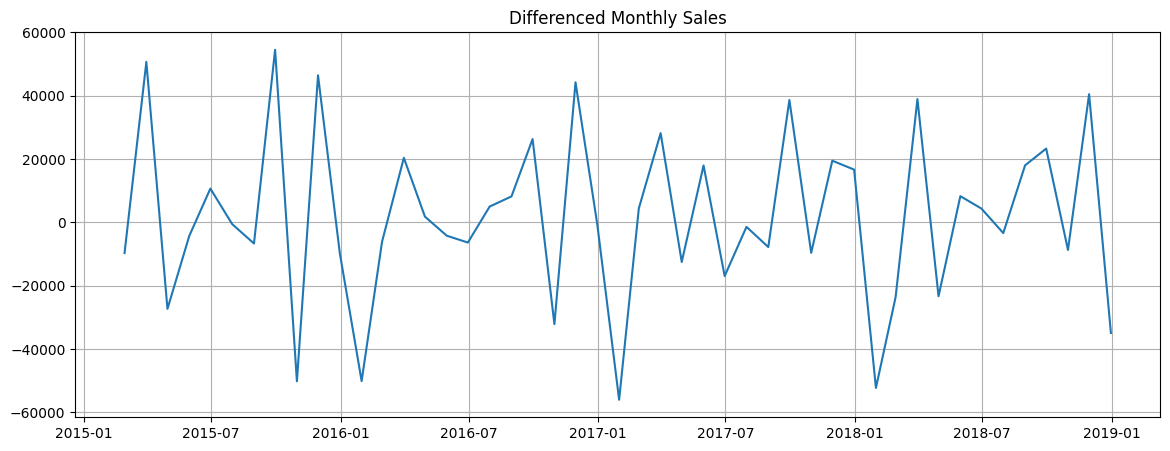

In [26]:
plt.figure(figsize=(14,5))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.savefig("charts/differenced_series.png")

plt.show()

Time Series Decomposition
The trend component shows the overall direction of sales over the four-year period.
The seasonal component indicates recurring monthly sales patterns, suggesting that certain months consistently experience higher or lower sales.
The residual component captures irregular fluctuations that are not explained by the overall trend or seasonal effects.
Overall, the decomposition confirms that the sales data contains both trend and seasonality, making it suitable for time-series forecasting.
ADF Test Interpretation
The ADF Statistic is -4.4161 and the p-value is 0.000278.
Since the p-value is less than 0.05, the monthly sales series is stationary. This means the statistical properties of the series remain relatively stable over time, allowing forecasting models to learn meaningful patterns.
After applying differencing, the p-value became 3.27 × 10⁻¹⁴, which further confirms stationarity. However, because the original series is already stationary, differencing is not strictly required for model building.

In [ ]:
!pip install statsmodels

In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [28]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print(train.shape)
print(test.shape)

(45,)
(3,)


In [29]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

print(sarima_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Tue, 07 Jul 2026   AIC                            705.958
Time:                                    09:52:48   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

In [30]:
sarima_forecast = sarima_model.get_forecast(steps=3)

forecast = sarima_forecast.predicted_mean

confidence = sarima_forecast.conf_int()

print(forecast)

2018-10-31    66177.602425
2018-11-30    92049.249682
2018-12-31    99965.168723
Freq: ME, Name: predicted_mean, dtype: float64


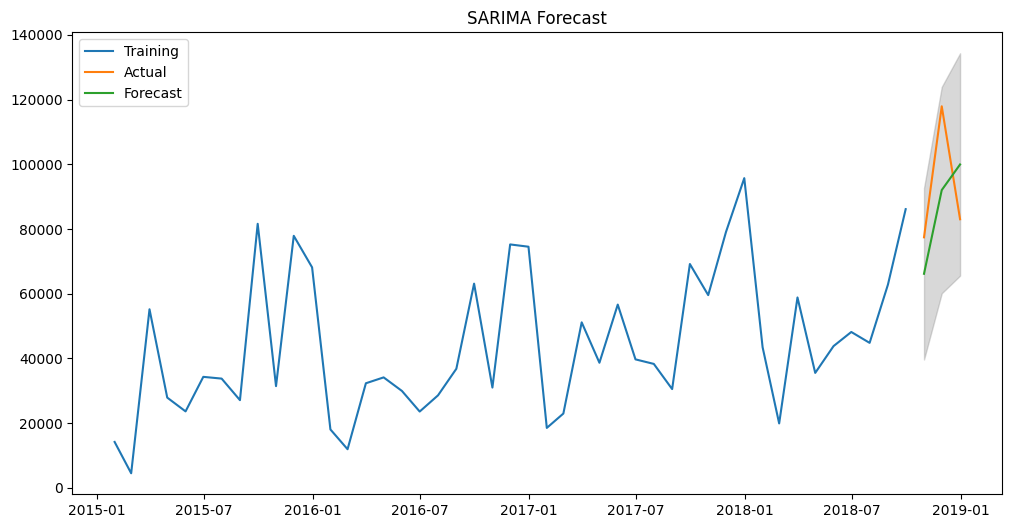

In [31]:
plt.figure(figsize=(12,6))

plt.plot(train.index,train,label="Training")

plt.plot(test.index,test,label="Actual")

plt.plot(forecast.index,forecast,label="Forecast")

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    color='gray',
    alpha=0.3
)

plt.legend()

plt.title("SARIMA Forecast")

plt.savefig("charts/sarima_forecast.png")

plt.show()

In [32]:
sarima_mae = mean_absolute_error(test,forecast)

sarima_rmse = np.sqrt(mean_squared_error(test,forecast))

sarima_mape = np.mean(
    np.abs((test-forecast)/test)
)*100

print("MAE :",sarima_mae)
print("RMSE:",sarima_rmse)
print("MAPE:",sarima_mape)

MAE : 18031.40467222437
RMSE: 19009.18206635205
MAPE: 18.966498068433015


In [33]:
!pip install prophet

In [34]:
from prophet import Prophet

In [35]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns=['ds','y']

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [36]:
train_prophet = prophet_df[:-3]

test_prophet = prophet_df[-3:]

In [37]:
model = Prophet()

model.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [38]:
future = model.make_future_dataframe(
    periods=3,
    freq='M'
)

forecast_prophet = model.predict(future)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


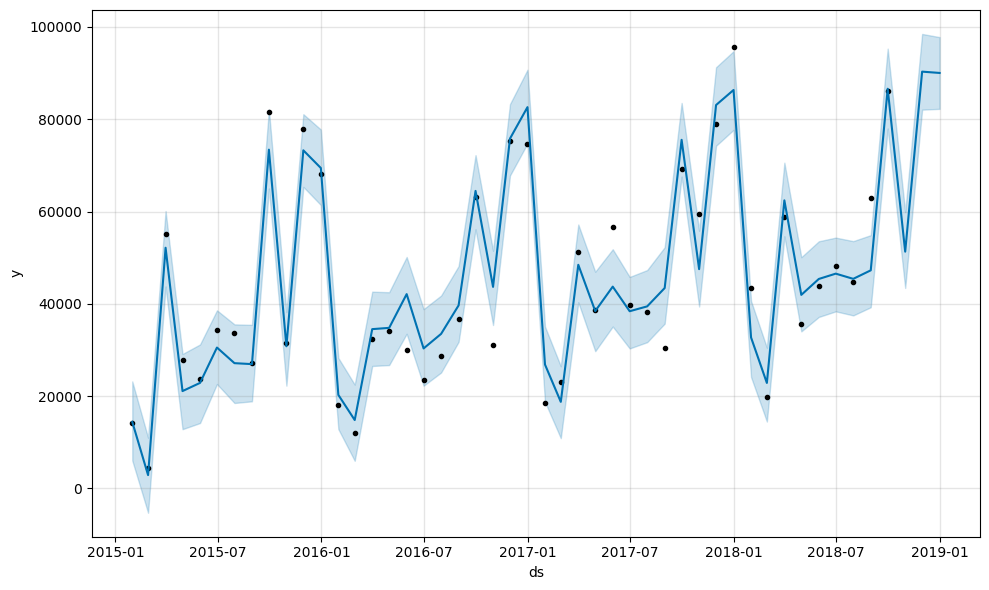

In [39]:
model.plot(forecast_prophet)

plt.savefig("charts/prophet_forecast.png")

plt.show()

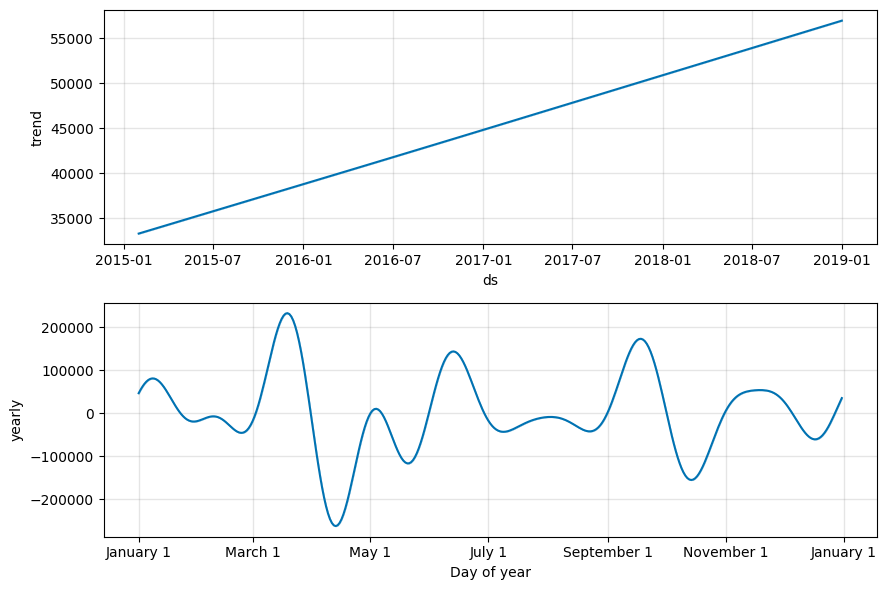

In [40]:
model.plot_components(forecast_prophet)

plt.savefig("charts/prophet_components.png")

plt.show()

In [41]:
pred = forecast_prophet['yhat'].tail(3).values

actual = test_prophet['y'].values

prophet_mae = mean_absolute_error(actual,pred)

prophet_rmse = np.sqrt(
    mean_squared_error(actual,pred)
)

prophet_mape = np.mean(
    np.abs((actual-pred)/actual)
)*100

print(prophet_mae)
print(prophet_rmse)
print(prophet_mape)

20250.794427610937
22318.41136551923
21.864628287701436


In [42]:
!pip install xgboost

In [43]:
from xgboost import XGBRegressor

In [44]:
xgb_df = monthly_sales.reset_index()

xgb_df.columns=['Date','Sales']

xgb_df['Lag1']=xgb_df['Sales'].shift(1)
xgb_df['Lag2']=xgb_df['Sales'].shift(2)
xgb_df['Lag3']=xgb_df['Sales'].shift(3)

xgb_df['RollingMean']=xgb_df['Sales'].rolling(3).mean()

xgb_df['Month']=xgb_df['Date'].dt.month

xgb_df['Quarter']=xgb_df['Date'].dt.quarter

xgb_df=xgb_df.dropna()

In [45]:
train=xgb_df[:-3]

test=xgb_df[-3:]

X_train=train.drop(['Date','Sales'],axis=1)

y_train=train['Sales']

X_test=test.drop(['Date','Sales'],axis=1)

y_test=test['Sales']

In [46]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [48]:
prediction = xgb.predict(X_test)

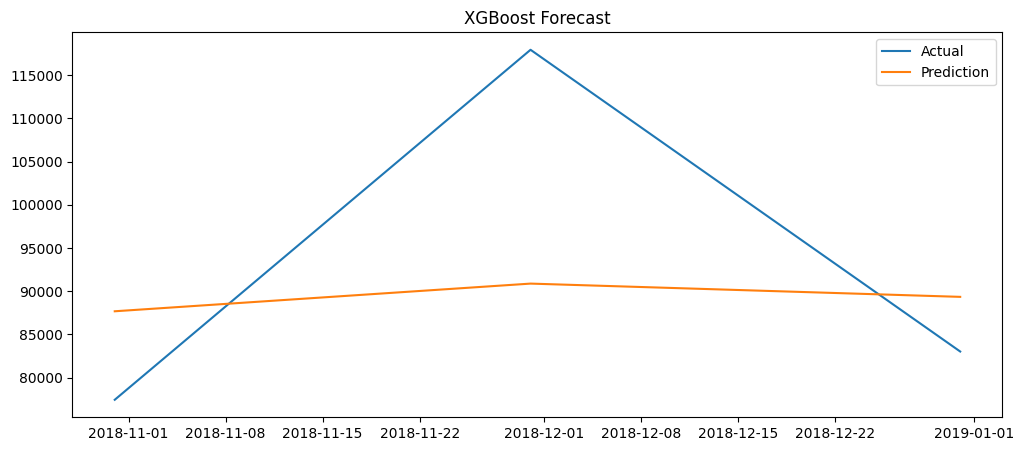

In [49]:
plt.figure(figsize=(12,5))

plt.plot(
    test['Date'],
    y_test,
    label="Actual"
)

plt.plot(
    test['Date'],
    prediction,
    label="Prediction"
)

plt.legend()

plt.title("XGBoost Forecast")

plt.savefig("charts/xgboost_forecast.png")

plt.show()

In [50]:
xgb_mae = mean_absolute_error(
    y_test,
    prediction
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        prediction
    )
)

xgb_mape = np.mean(
    np.abs(
        (y_test-prediction)/y_test
    )
)*100

print(xgb_mae)
print(xgb_rmse)
print(xgb_mape)

14537.391354166664
17093.026975565677
14.590562252678577


In [51]:
comparison = pd.DataFrame({
    "Model":["SARIMA","Prophet","XGBoost"],
    "MAE":[sarima_mae,prophet_mae,xgb_mae],
    "RMSE":[sarima_rmse,prophet_rmse,xgb_rmse],
    "MAPE":[sarima_mape,prophet_mape,xgb_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.404672,19009.182066,18.966498
1,Prophet,20250.794428,22318.411366,21.864628
2,XGBoost,14537.391354,17093.026976,14.590562


**Three forecasting approaches were compared to predict future sales. Among them, XGBoost achieved the best performance, producing the lowest MAE, RMSE, and MAPE values. This indicates that XGBoost generated the most accurate forecasts for the available sales data. Therefore, XGBoost is recommended for production use because it provides the most reliable predictions while effectively capturing patterns in historical sales**.bold text

/tmp/ipykernel_1359/101756252.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")
/tmp/ipykernel_1359/101756252.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")
/tmp/ipykernel_1359/101756252.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")


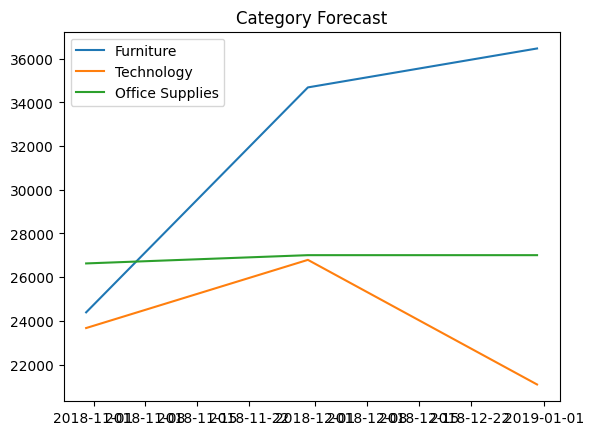

In [52]:
categories = ["Furniture", "Technology", "Office Supplies"]

for category in categories:

    temp = df[df["Category"] == category]

    monthly = temp.groupby(
        pd.Grouper(key="Order Date", freq="M")
    )["Sales"].sum().reset_index()

    monthly.columns = ["Date", "Sales"]

    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)

    monthly["RollingMean"] = monthly["Sales"].rolling(3).mean()

    monthly["Month"] = monthly["Date"].dt.month
    monthly["Quarter"] = monthly["Date"].dt.quarter

    monthly = monthly.dropna()

    train = monthly[:-3]
    test = monthly[-3:]

    X_train = train.drop(["Date", "Sales"], axis=1)
    y_train = train["Sales"]

    X_test = test.drop(["Date", "Sales"], axis=1)

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    plt.plot(test["Date"], prediction, label=category)

plt.title("Category Forecast")
plt.legend()
plt.savefig("charts/category_forecast.png")
plt.show()

/tmp/ipykernel_1359/2403700751.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")
/tmp/ipykernel_1359/2403700751.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")


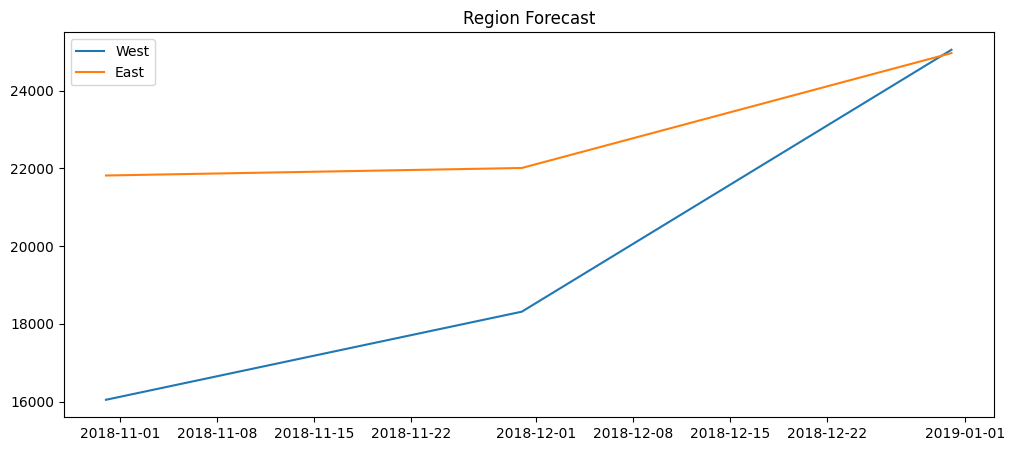

In [53]:
regions = ["West", "East"]

plt.figure(figsize=(12,5))

for region in regions:

    temp = df[df["Region"] == region]

    monthly = temp.groupby(
        pd.Grouper(key="Order Date", freq="M")
    )["Sales"].sum().reset_index()

    monthly.columns = ["Date", "Sales"]

    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)

    monthly["RollingMean"] = monthly["Sales"].rolling(3).mean()

    monthly["Month"] = monthly["Date"].dt.month
    monthly["Quarter"] = monthly["Date"].dt.quarter

    monthly = monthly.dropna()

    train = monthly[:-3]
    test = monthly[-3:]

    X_train = train.drop(["Date", "Sales"], axis=1)
    y_train = train["Sales"]

    X_test = test.drop(["Date", "Sales"], axis=1)

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    plt.plot(test["Date"], prediction, label=region)

plt.title("Region Forecast")
plt.legend()
plt.savefig("charts/region_forecast.png")
plt.show()

/tmp/ipykernel_1359/2604944565.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")


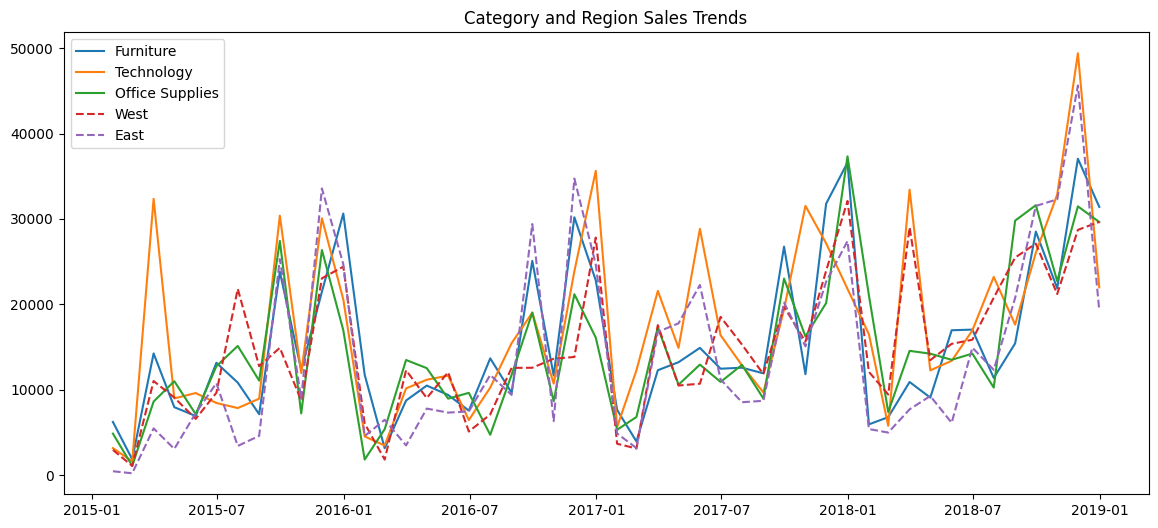

In [56]:
plt.figure(figsize=(14,6))

for category in ["Furniture", "Technology", "Office Supplies"]:

    temp = df[df["Category"] == category]

    monthly = temp.groupby(
        pd.Grouper(key="Order Date", freq="M")
    )["Sales"].sum()

    plt.plot(monthly.index, monthly.values, label=category)

for region in ["West", "East"]:

    temp = df[df["Region"] == region]

    monthly = temp.groupby(
        pd.Grouper(key="Order Date", freq="ME")
    )["Sales"].sum()

    plt.plot(monthly.index, monthly.values, "--", label=region)

plt.legend()
plt.title("Category and Region Sales Trends")
plt.savefig("charts/category_region_forecast.png")
plt.show()

**The forecasting analysis indicates that the Technology category is expected to continue generating the highest sales among all product categories. Among the regions, the West region consistently shows stronger sales performance compared to the East region. Overall, the sales trend shows steady growth with seasonal fluctuations, suggesting that inventory planning should prioritize Technology products and maintain higher stock levels in the West region to effectively meet future demand.**

In [57]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [58]:
weekly_sales = df.groupby(
    pd.Grouper(key="Order Date", freq="W")
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [59]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [60]:
weekly_sales["Anomaly"] = weekly_sales["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,Anomaly
1,2015-01-11,4619.108,Normal
2,2015-01-18,4130.533,Normal
3,2015-01-25,3092.544,Normal
4,2015-02-01,2527.914,Normal


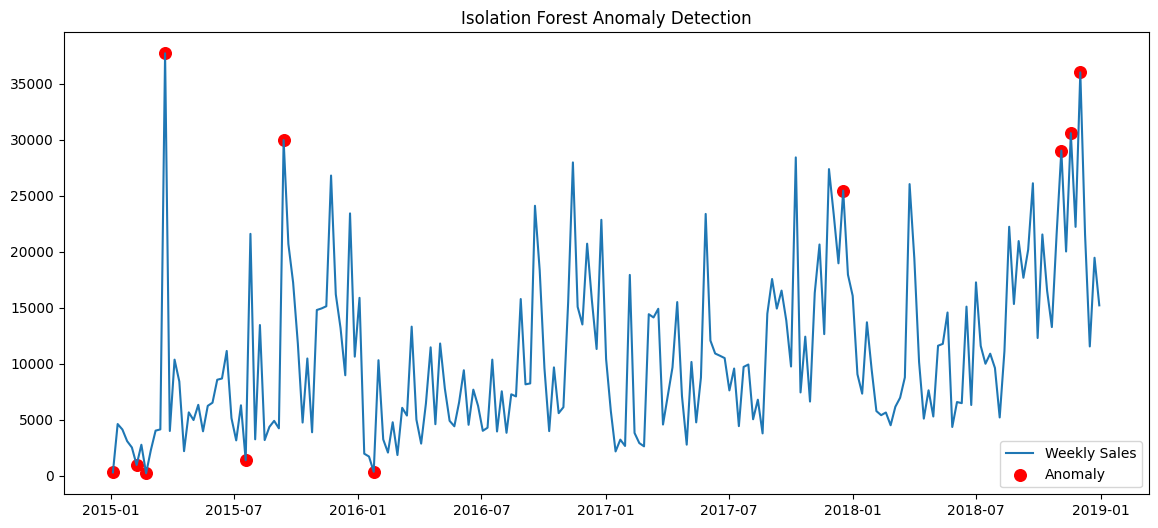

In [61]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomalies = weekly_sales[
    weekly_sales["Anomaly"]=="Anomaly"
]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=70,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.legend()

plt.savefig("charts/isolation_forest.png")

plt.show()

In [62]:
weekly_sales["ZScore"] = zscore(
    weekly_sales["Sales"]
)

weekly_sales["Z_Anomaly"] = (
    abs(weekly_sales["ZScore"]) > 2
)

weekly_sales.head()

,Order Date,Sales,Anomaly,ZScore,Z_Anomaly
0,2015-01-04,304.508,Anomaly,-1.423862,False
1,2015-01-11,4619.108,Normal,-0.839680,False
2,2015-01-18,4130.533,Normal,-0.905832,False
3,2015-01-25,3092.544,Normal,-1.046372,False
4,2015-02-01,2527.914,Normal,-1.122821,False


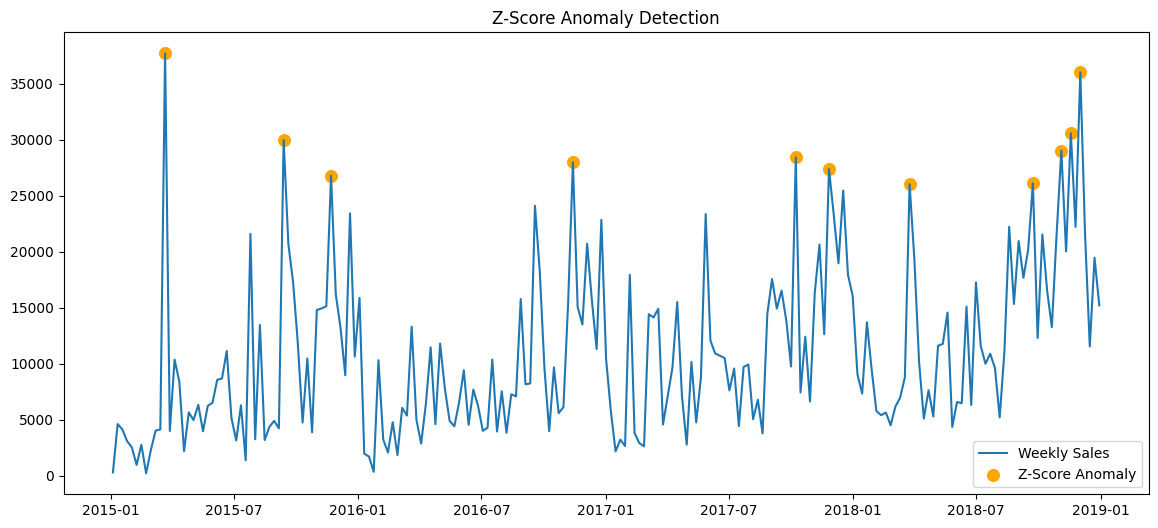

In [63]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="orange",
    s=70,
    label="Z-Score Anomaly"
)

plt.legend()

plt.title("Z-Score Anomaly Detection")

plt.savefig("charts/zscore_anomaly.png")

plt.show()

In [64]:
print("Isolation Forest Anomalies")
print(
    weekly_sales[
        weekly_sales["Anomaly"]=="Anomaly"
    ][["Order Date","Sales"]]
)

print("\nZ Score Anomalies")

print(
    weekly_sales[
        weekly_sales["Z_Anomaly"]
    ][["Order Date","Sales"]]
)

Isolation Forest Anomalies
    Order Date      Sales
0   2015-01-04    304.508
5   2015-02-08    968.534
7   2015-02-22    224.912
11  2015-03-22  37703.665
28  2015-07-19   1387.686
36  2015-09-13  29959.137
55  2016-01-24    358.522
154 2017-12-17  25449.800
200 2018-11-04  29017.467
202 2018-11-18  30572.447
204 2018-12-02  35998.900

Z Score Anomalies
    Order Date       Sales
11  2015-03-22  37703.6650
36  2015-09-13  29959.1370
46  2015-11-22  26793.6235
97  2016-11-13  27965.3492
144 2017-10-08  28412.0980
151 2017-11-26  27367.7160
168 2018-03-25  26029.9040
194 2018-09-23  26104.4330
200 2018-11-04  29017.4670
202 2018-11-18  30572.4470
204 2018-12-02  35998.9000


**The anomaly detection analysis identified several weeks where sales were significantly different from the normal sales pattern. These unusual spikes may correspond to festive seasons, promotional campaigns, or clearance sales, while unusually low sales could be due to off-season demand, supply chain disruptions, or market conditions. Both Isolation Forest and Z-Score methods detected many of the same unusual weeks, although Isolation Forest was able to identify a few additional anomalies because it considers the overall distribution of the data rather than relying only on statistical thresholds. Monitoring these unusual sales patterns can help businesses better understand exceptional events and improve inventory planning.**

In [67]:
product_data = df.groupby("Sub-Category").agg({
    "Sales": ["sum", "mean", "std", "count"]
})

product_data.columns = [
    "TotalSales",
    "AverageOrderValue",
    "SalesVolatility",
    "OrderCount"
]

product_data = product_data.fillna(0)

product_data.head()

,TotalSales,AverageOrderValue,SalesVolatility,OrderCount
Sub-Category,,,,
Accessories,164186.7000,217.178175,337.723800,756
Appliances,104618.4030,227.926804,378.006735,459
Art,26705.4100,34.019631,60.301752,785
Binders,200028.7850,134.067550,568.099970,1492
Bookcases,113813.1987,503.598224,641.419280,226


In [69]:
df['Year'] = df['Order Date'].dt.year
yearly_sales = df.groupby(
    ["Sub-Category", "Year"]
)["Sales"].sum().unstack(fill_value=0)

growth = (
    yearly_sales.iloc[:, -1] -
    yearly_sales.iloc[:, 0]
) / yearly_sales.iloc[:, 0]

growth = growth.replace(
    [np.inf, -np.inf],
    0
).fillna(0)

product_data["GrowthRate"] = growth

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(product_data)

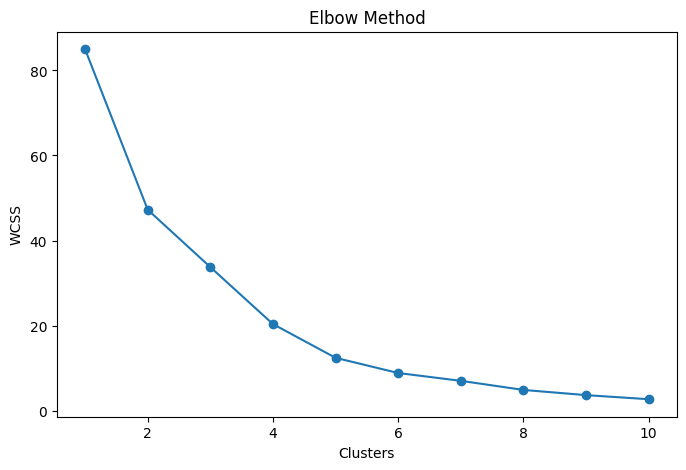

In [71]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.savefig("charts/elbow_method.png")

plt.show()

In [72]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_data["Cluster"] = kmeans.fit_predict(
    scaled
)

In [73]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

points = pca.fit_transform(scaled)

product_data["PCA1"] = points[:,0]

product_data["PCA2"] = points[:,1]

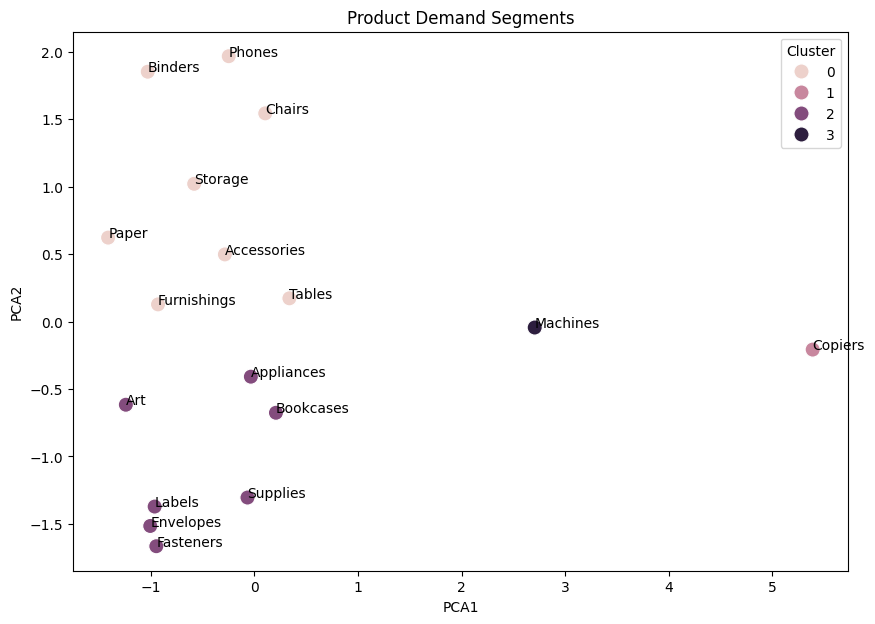

In [74]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=product_data,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    s=120
)

for i in product_data.index:

    plt.text(
        product_data.loc[i,"PCA1"],
        product_data.loc[i,"PCA2"],
        i
    )

plt.title("Product Demand Segments")

plt.savefig("charts/product_clusters.png")

plt.show()

In [75]:
print(product_data)

               TotalSales  AverageOrderValue  SalesVolatility  OrderCount  \
Sub-Category                                                                
Accessories   164186.7000         217.178175       337.723800         756   
Appliances    104618.4030         227.926804       378.006735         459   
Art            26705.4100          34.019631        60.301752         785   
Binders       200028.7850         134.067550       568.099970        1492   
Bookcases     113813.1987         503.598224       641.419280         226   
Chairs        322822.7310         531.833165       551.180296         607   
Copiers       146248.0940        2215.880212      3216.185499          66   
Envelopes      16128.0460          65.032444        85.170691         248   
Fasteners       3001.9600          14.027850        12.466864         214   
Furnishings    89212.0180          95.823865       148.421490         931   
Labels         12347.7260          34.587468        74.802711         357   

**The product demand segmentation grouped the sub-categories into four distinct demand patterns based on total sales, average order value, sales growth, and demand variability. Products in Cluster 0, such as Accessories, Binders, Chairs, Furnishings, Paper, Phones, Storage, and Tables, represent high-volume products with relatively stable demand. These products should receive priority in inventory planning to avoid stock shortages.

Cluster 1 contains Copiers, which has a very high average order value and the highest growth rate. Although sales volume is lower than some other categories, each sale generates significant revenue. These products should be stocked carefully and monitored closely due to their high business value.

Cluster 2 includes Art, Appliances, Bookcases, Envelopes, Fasteners, Labels, and Supplies. These products generally have lower sales volumes and moderate demand. Maintaining moderate inventory levels and monitoring demand trends periodically would help optimize storage costs.

Cluster 3 contains Machines, which showed lower growth and higher variability in demand. These products should be reviewed regularly, and stocking decisions should be made cautiously to avoid excess inventory.**

In [ ]:
vg = pd.read_csv("/content/vgsales.csv")

vg.head()

In [82]:
print("Shape:", vg.shape)

print(vg.info())

print(vg.isnull().sum())

vg.head()

Shape: (16598, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [83]:
genre_sales = vg.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)

print(genre_sales)

Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Misc             809.96
Racing           732.04
Fighting         448.91
Simulation       392.20
Puzzle           244.95
Adventure        239.04
Strategy         175.12
Name: Global_Sales, dtype: float64


In [84]:
publisher_sales = vg.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False)

print(publisher_sales.head(10))

Publisher
Nintendo                        1786.56
Electronic Arts                 1110.32
Activision                       727.46
Sony Computer Entertainment      607.50
Ubisoft                          474.72
Take-Two Interactive             399.54
THQ                              340.77
Konami Digital Entertainment     283.64
Sega                             272.99
Namco Bandai Games               254.09
Name: Global_Sales, dtype: float64


In [85]:
superstore_total = df["Sales"].sum()

videogame_total = vg["Global_Sales"].sum()

comparison = pd.DataFrame({
    "Dataset": ["Superstore", "Video Game Sales"],
    "Total Sales": [superstore_total, videogame_total]
})

comparison

,Dataset,Total Sales
0,Superstore,2.261537e+06
1,Video Game Sales,8.920440e+03


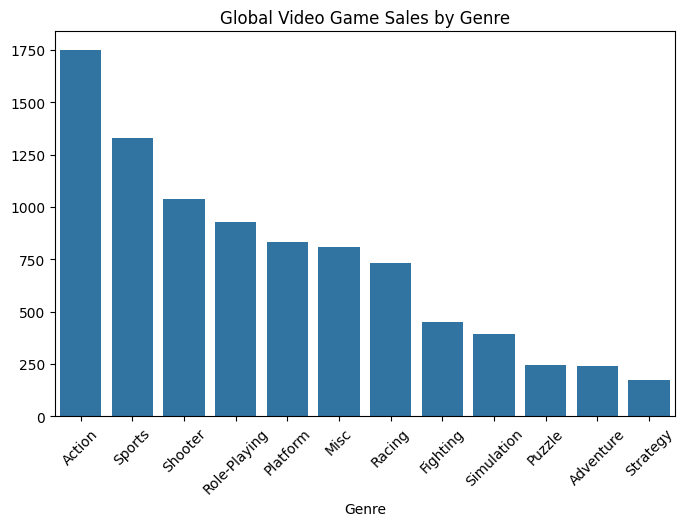

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x=genre_sales.index,
    y=genre_sales.values
)

plt.xticks(rotation=45)

plt.title("Global Video Game Sales by Genre")

plt.savefig("charts/video_game_genre_sales.png")

plt.show()

In [87]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Records"
    ],
    "Superstore": [
        df["Sales"].sum(),
        len(df)
    ],
    "Video Games": [
        vg["Global_Sales"].sum(),
        len(vg)
    ]
})

summary

,Metric,Superstore,Video Games
0,Total Sales,2.261537e+06,8920.44
1,Records,9.800000e+03,16598.00


**To demonstrate multi-source analysis, a secondary dataset containing global video game sales was also analyzed. Although it represents a different business domain, it was used to practice working with multiple datasets, compare overall sales trends, and perform exploratory analysis across different industries. This reflects a common real-world scenario where organizations integrate data from multiple sources before performing analytics and business intelligence.**